# Clusterização de municípios — regiões com padrões semelhantes

Pergunta de negócio: quais regiões apresentam padrões semelhantes entre si? Diferente do modelo
supervisionado (`atingiu_meta`), aqui não há rótulo — o objetivo é agrupar municípios por perfil
territorial, populacional, socioeconômico e educacional (K-Means) e só depois verificar como esses
grupos se distribuem entre as regiões oficiais e o desfecho de alfabetização.

Lógica completa em `src/modeling/clustering.py` (script reprodutível, `python
src/modeling/clustering.py`, que gera `reports/clustering_profile.json` e as imagens usadas aqui).

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from src.modeling.clustering import (
    load_snapshot,
    build_preprocessor,
    CLUSTER_FEATURES,
    PROFILE_ONLY_COLUMNS,
    choose_k,
    profile_clusters,
    RANDOM_STATE,
    SNAPSHOT_YEAR,
)

sns.set_theme(style="whitegrid")
IMAGES_DIR = Path("../images")

with open("../reports/clustering_profile.json", encoding="utf-8") as f:
    report = json.load(f)

df = load_snapshot()
df = df.dropna(subset=["populacao", "pib"]).reset_index(drop=True)
print(f"Municípios no snapshot {SNAPSHOT_YEAR}: {len(df)}")
df[CLUSTER_FEATURES + PROFILE_ONLY_COLUMNS].head()

Municípios no snapshot 2024: 5232


,populacao,pib,taxa_aprovacao_ef_anos_iniciais,taxa_reprovacao_ef_anos_iniciais,taxa_abandono_ef_anos_iniciais,tdi_ef_anos_iniciais,atu_ef_anos_iniciais,dsu_ef_anos_iniciais,capital_uf,amazonia_legal,sigla_uf,nome_regiao,taxa_alfabetizacao,atingiu_meta
0,22853,1046343000,81.1,4.8,30.7,14.4,2.0,17.0,0,1,RO,Norte,67.79,1
1,108573,4383815000,97.7,4.5,23.6,25.8,1.3,11.1,0,1,RO,Norte,65.62,1
2,5690,300832000,100.0,4.1,27.7,14.8,21.0,10.8,0,1,RO,Norte,75.88,1
3,97637,3848468000,93.6,4.8,23.7,17.3,3.4,11.1,0,1,RO,Norte,66.07,1
4,16975,1006389000,100.0,4.0,13.3,22.5,0.0,8.2,0,1,RO,Norte,66.81,1


**Snapshot de 2024** (5.232 municípios, mais completo que 2023) representa o retrato mais atual
disponível. `sigla_uf` e `nome_regiao` **não entram como feature de agrupamento** — entrariam de
forma circular, já que a própria pergunta é se os clusters formados coincidem ou não com as
regiões oficiais. Elas são usadas só depois, para caracterizar os grupos encontrados. Pelo mesmo
motivo, `taxa_alfabetizacao` e `atingiu_meta` também ficam de fora das features (são desfecho, não
perfil) e só entram na etapa de perfilamento dos clusters já formados.

In [2]:
preprocessor = build_preprocessor()
X = preprocessor.fit_transform(df[CLUSTER_FEATURES])
X.shape

(5232, 10)

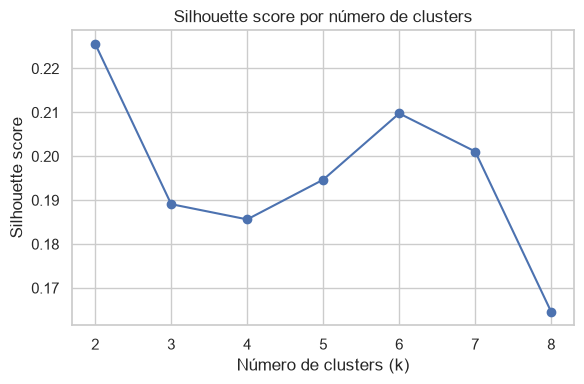

,k,silhouette
0,2,0.225605
1,3,0.189090
2,4,0.185621
3,5,0.194667
4,6,0.209765
5,7,0.201082
6,8,0.164555


In [3]:
k_scores = pd.DataFrame(report["silhouette_por_k"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_scores["k"], k_scores["silhouette"], marker="o", color="#4C72B0")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score por número de clusters")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "17_silhouette_por_k.png", dpi=120)
plt.show()
k_scores

Os scores são modestos em todos os valores de k testados (0,16 a 0,23) — municípios se
distribuem ao longo de um contínuo socioeconômico/educacional, não em grupos fortemente separados,
o que é esperado dado que a maioria das features é contínua. Ainda assim, **k=2** tem o maior
silhouette score (0,226) e, como visto abaixo, produz dois perfis com diferença real de desfecho —
critério usado para a escolha final em vez de um k maior com separação mais fraca.

In [4]:
kmeans = KMeans(n_clusters=report["k_escolhido"], random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
df["cluster"] = labels
df["cluster"].value_counts().sort_index()

cluster
0    3931
1    1301
Name: count, dtype: int64

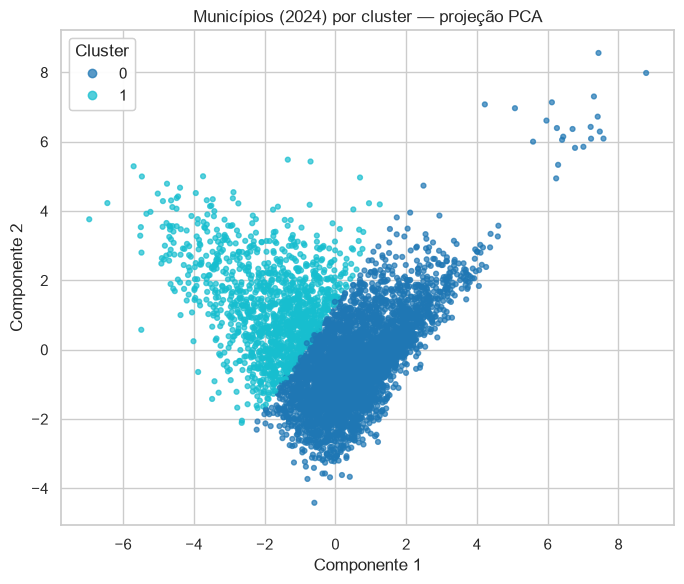

In [5]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=12, alpha=0.7)
ax.set_title(f"Municípios ({SNAPSHOT_YEAR}) por cluster — projeção PCA")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "15_clusters_pca.png", dpi=120)
plt.show()

A separação na projeção PCA não é nítida (reforça os silhouette scores baixos), mas há uma
tendência visível de concentração diferente entre os dois grupos, consistente com o perfil abaixo.

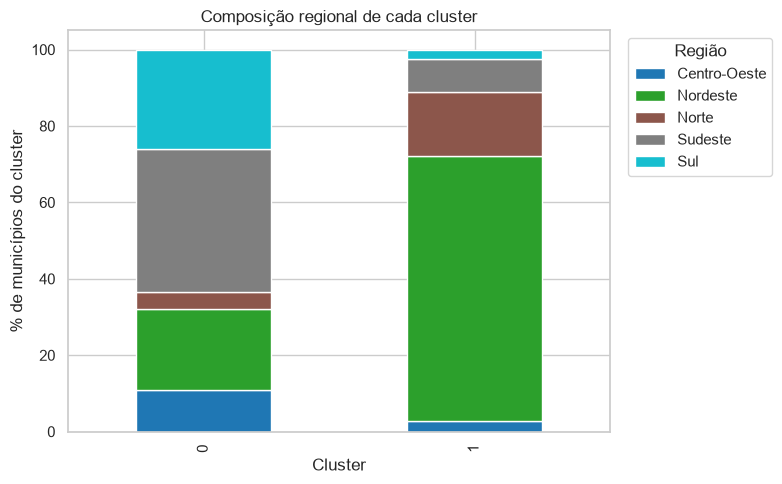

nome_regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
cluster,,,,,
0,10.8,21.3,4.4,37.6,26.0
1,2.8,69.3,16.8,8.7,2.5


In [6]:
composicao = pd.crosstab(df["cluster"], df["nome_regiao"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 5))
composicao.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Composição regional de cada cluster")
ax.set_ylabel("% de municípios do cluster")
ax.set_xlabel("Cluster")
ax.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "16_clusters_por_regiao.png", dpi=120)
plt.show()
composicao.round(1)

In [7]:
perfil = profile_clusters(df[CLUSTER_FEATURES + PROFILE_ONLY_COLUMNS], labels)
perfil_df = pd.DataFrame(perfil).drop(columns=["composicao_regional_pct"])
perfil_df

,cluster,n_municipios,pct_atingiu_meta,taxa_alfabetizacao_media,populacao_mediana,pib_mediano,pct_capital_uf,pct_amazonia_legal,dsu_ef_anos_iniciais_media
0,0,3931,56.1,66.4,11371.0,382795000.0,0.5,7.8,15.4
1,1,1301,47.1,54.9,12312.0,202680000.0,0.0,30.9,27.5


**Cluster 0** (3.931 municípios, 75% do total): concentrado em Sudeste (37,6%), Sul (26,0%) e
parte do Nordeste (21,3%); quase nenhuma presença na Amazônia Legal (7,8%); menor percentual de
docentes com curso superior nos anos iniciais (`dsu_ef_anos_iniciais` médio 15,4%); **56,1% dos
municípios atingiram a meta**, com taxa de alfabetização média de 66,4%.

**Cluster 1** (1.301 municípios, 25% do total): fortemente concentrado no Nordeste (69,3%) e Norte
(16,8%); quase um terço na Amazônia Legal (30,9%); maior percentual de docentes com curso superior
(27,5% em média — quase o dobro do cluster 0); **apenas 47,1% atingiram a meta**, com taxa de
alfabetização média de 54,9%.

Isso conecta dois achados que antes apareciam isolados na análise exploratória e na modelagem: a
UF/região concentra o sinal mais forte do modelo supervisionado, e `dsu_ef_anos_iniciais`
correlaciona negativamente com o alvo em todas as regiões. A clusterização mostra que esse padrão
contraintuitivo não é um ruído pontual — ele faz parte de um perfil regional inteiro (Nordeste/
Norte/Amazônia Legal, com mais professores com curso superior e, mesmo assim, pior desempenho em
alfabetização), reforçando que a causa provável está em outros fatores não capturados neste
dataset (infraestrutura, contexto socioeconômico das famílias, avaliação regional), não na
formação docente isoladamente.

## Resposta à pergunta de negócio

Os municípios brasileiros se agrupam em dois perfis principais, não em várias regiões
independentes: um perfil concentrado em Sudeste/Sul (e parte do Nordeste), com melhor desempenho
em alfabetização, e um perfil concentrado em Nordeste/Norte/Amazônia Legal, com desempenho pior
apesar de indicadores de formação docente mais altos. Os silhouette scores baixos (0,16-0,23)
indicam que essa divisão é uma tendência real, mas não uma fronteira rígida — há um contínuo de
municípios entre os dois perfis, coerente com a natureza gradual das desigualdades regionais
brasileiras.